In [12]:
import pandas as pd
import numpy as np

In [13]:
df = pd.read_csv('/home/mouryesh/mouryesh/Online_retail_dataset/data/OnlineRetail.csv', encoding='ISO-8859-1')

In [14]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [15]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [17]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [22]:
print("Number of rows with zero or negative quantity:", (df['Quantity'] <= 0).sum())
print("Number of rows with zero or negative unit price:", (df['UnitPrice'] <= 0).sum())

Number of rows with zero or negative quantity: 10624
Number of rows with zero or negative unit price: 2517


In [23]:
df.duplicated().sum()

np.int64(5268)

In [24]:
df[df['Quantity'] < 0].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [26]:
df[df['UnitPrice'] <= 0].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [27]:
df['InvoiceNo'].astype(str).str[0].value_counts()

InvoiceNo
5    532618
C      9288
A         3
Name: count, dtype: int64

In [33]:
df = df[df['CustomerID'].notnull()]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df.drop_duplicates()
df = df[df['UnitPrice'] > 0]

In [34]:
df['total_price'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   total_price  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [36]:
df.shape

(392692, 9)

In [37]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,total_price
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [38]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   lambda x: x.nunique()),        # count unique invoices
    Monetary  = ('total_price', 'sum')                      # total spent
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [39]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [41]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [42]:
from sklearn.preprocessing import StandardScaler
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled.describe()   # confirm mean≈0, std≈1


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,-3.669008e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-3.997811e+00
25%,-6.613615e-01,-9.552143e-01,-6.835802e-01
50%,8.992557e-02,-3.615828e-01,-6.510929e-02
75%,8.447915e-01,6.532370e-01,6.572178e-01
max,1.564198e+00,5.858535e+00,4.732381e+00


In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

# print them so you can read the numbers
for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"k={k}  inertia={inertia:.0f}  silhouette={sil:.3f}")


k=2  inertia=6484  silhouette=0.433
k=3  inertia=4869  silhouette=0.337
k=4  inertia=3939  silhouette=0.338
k=5  inertia=3297  silhouette=0.316
k=6  inertia=2856  silhouette=0.312
k=7  inertia=2549  silhouette=0.309
k=8  inertia=2336  silhouette=0.303
k=9  inertia=2156  silhouette=0.281
k=10  inertia=2006  silhouette=0.277


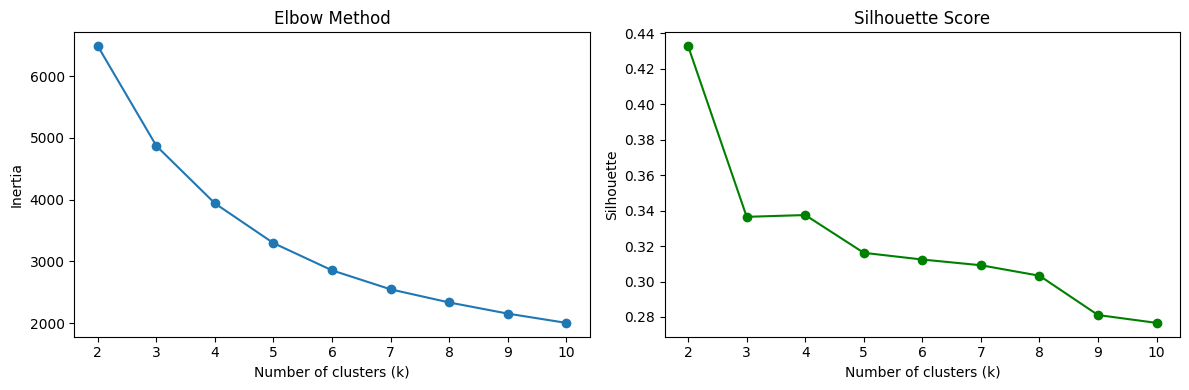

In [44]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, marker='o', color='green')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette')

plt.tight_layout()
plt.show()


In [45]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


In [46]:
cluster_profile = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Count=('Recency', 'count')     # how many customers in each cluster
).round(1)

cluster_profile


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,12.2,13.8,8088.0,713
1,181.5,1.3,341.0,1622
2,17.7,2.2,557.3,837
3,71.6,4.1,1801.8,1166


In [47]:
segment_names = {
    0: 'Champions',
    1: 'Lost',
    2: 'New Customers',
    3: 'Loyal / At-Risk'
}
rfm['Segment'] = rfm['Cluster'].map(segment_names)
rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal / At-Risk
12347.0,2,7,4310.00,0,Champions
12348.0,75,4,1797.24,3,Loyal / At-Risk
12349.0,19,1,1757.55,2,New Customers
12350.0,310,1,334.40,1,Lost


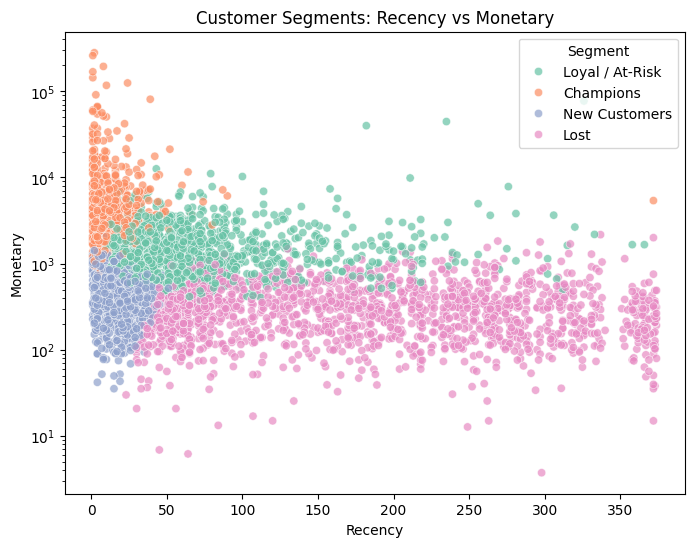

In [48]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='Set2', alpha=0.7)
plt.yscale('log')   # Monetary is skewed, log makes clusters visible
plt.title('Customer Segments: Recency vs Monetary')
plt.show()


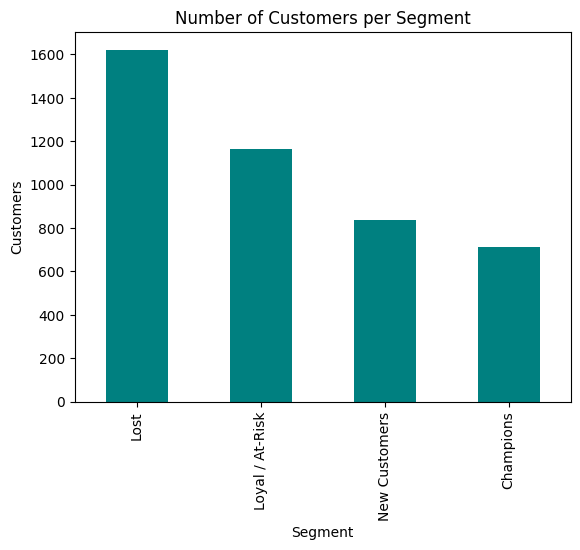

In [49]:
rfm['Segment'].value_counts().plot(kind='bar', color='teal')
plt.title('Number of Customers per Segment')
plt.ylabel('Customers')
plt.show()


In [50]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = rfm['Cluster']
print(f"Silhouette Score:      {silhouette_score(rfm_scaled, labels):.3f}  (higher better)")
print(f"Davies-Bouldin Index:  {davies_bouldin_score(rfm_scaled, labels):.3f}  (lower better)")
print(f"Calinski-Harabasz:     {calinski_harabasz_score(rfm_scaled, labels):.0f}  (higher better)")


Silhouette Score:      0.338  (higher better)
Davies-Bouldin Index:  1.009  (lower better)
Calinski-Harabasz:     3328  (higher better)
